# KNN

- Why we need KNN when we have other algo?
- ANS: KNN makes **zero assumptions** about the dataset
- Others like Linear regression assumes data is linearly seperable
- Decision tree assume , data splits at threshold
- If data violates any of this, the performance drop
- With KNN this is not the case, you tell KNN, K who your neighbors are, and it will find K closets datapoints where it belongs
- KNN directly stores the training dataset
-------------------------------------------------------------
- Also, a Lazy Learner
- There's no coefficent, weights, etc. The Model itself is training data. 
- Follows natural boundary no matter the complexity of data
---------------------------------------------------------------
- Always Pick an *ODD KNN** To avoid TIE
- K=1 , training data is 100% accuracy, every point is its own neighbour. Extreme overfit
- K=N(all training points) every prediction is identical. Extreme underfit
- Always, **SCALE (StandardScaler)** before using KNN, because the features aee on different scales, as largest scale will dominate the other. So, better to scale all features and bring on same page
-----------------------------------------------------------------

- K controls the bias-variance tradeoff
----------------------------------------

- Use **StandardScaler** - whene dataset contains Outliers
- Use **MinMax** - when dataset dose not contains  outliers
- Use **RobustScaler** - when to many Outliers
-------------------------------------------------------------------

**KNN for Regression** 
1. KNeighborsClassifier  -- Based on the vote -- predicts Class
2. KNeighborsRegressor --- Based on the average -- predicts Number

# Distance metrics 

1. Euclidean Distance -- deafult for sklearn
2. Manhattan distance
3. Minkowski Distance 

- As KNN calculate distance- it is sensitive to "MISSING VALUES" in the Data

-------------------------

- KNN Working

- If new datapoint comes in. It calculates it's distance with each row and its feature.
- eg: if in dataset there are 3 people with salary are 5 features. So the new person with have 5 features and will calculate the distance with each person's feature. And the less distance would be picked

# When KNN is THE Answer — Interview-Ready

The one-line interviewer answer:

"KNN when the decision boundary is complex and non-linear, data is small, and you need zero assumptions."


The 3 situations where KNN wins
1. Decision boundary is irregular/complex

Linear regression, logistic regression — draw a straight line.

KNN draws whatever shape the data makes.

→ If your data clusters in weird, curvy patterns — KNN fits naturally.
2. No time to train / quick baseline needed

KNN has zero training phase.

→ Useful when you need a fast working model to compare others against.
3. Local patterns matter more than global

Some datasets behave differently in different regions.

KNN captures local structure — it only looks at nearby points, not the whole dataset.

→ Example: recommender systems — "people similar to you specifically" not "people on average."

The interview trap to avoid ❌
Interviewer: "Why not just use Random Forest? It handles complex boundaries too."
Your answer:

"Random Forest still requires training and makes splits. KNN makes literally zero assumptions — it memorizes data as-is. For very small datasets with no clear pattern, KNN is simpler and often good enough without overfitting risk from tree splits."

# Why Scaling matter in KNN

- As the distance betweeen the feature is more , Large scale=large squared difference=which dominates the sum 
- As 1 feature distance increase it affectes the models decision. Hence, scale all the features on the same page


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_csv('c:/Desktop/Desktop/MS_AI_course/ML/dataset/marketing_campaign_response.csv')
df


,Age,Annual_Income_Lakhs,Past_Purchases,Email_Opens_90Days,Days_Since_Last_Purchase,Has_Mobile_App,Responded
0,22,27.8,5,18,73,1,1
1,36,23.2,4,10,298,1,1
2,31,21.1,4,8,225,1,0
3,39,21.4,0,29,235,0,0
4,26,26.5,4,15,76,1,0
...,...,...,...,...,...,...,...
495,47,4.7,5,0,89,1,1
496,58,10.3,2,20,186,1,1
497,39,15.7,1,8,12,1,0
498,30,8.9,5,19,106,0,1


In [22]:
df.head(10)

,Age,Annual_Income_Lakhs,Past_Purchases,Email_Opens_90Days,Days_Since_Last_Purchase,Has_Mobile_App,Responded
0,22,27.8,5,18,73,1,1
1,36,23.2,4,10,298,1,1
2,31,21.1,4,8,225,1,0
3,39,21.4,0,29,235,0,0
4,26,26.5,4,15,76,1,0
5,47,15.9,2,3,364,1,0
6,28,7.7,2,23,108,0,1
7,35,26.4,4,1,76,0,0
8,46,20.7,4,11,223,0,0
9,44,12.3,7,7,304,1,0


In [23]:
# Checking for null values
df.isna().sum()

Age                         0
Annual_Income_Lakhs         0
Past_Purchases              0
Email_Opens_90Days          0
Days_Since_Last_Purchase    0
Has_Mobile_App              0
Responded                   0
dtype: int64

In [24]:
df.dtypes

Age                           int64
Annual_Income_Lakhs         float64
Past_Purchases                int64
Email_Opens_90Days            int64
Days_Since_Last_Purchase      int64
Has_Mobile_App                int64
Responded                     int64
dtype: object

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       500 non-null    int64  
 1   Annual_Income_Lakhs       500 non-null    float64
 2   Past_Purchases            500 non-null    int64  
 3   Email_Opens_90Days        500 non-null    int64  
 4   Days_Since_Last_Purchase  500 non-null    int64  
 5   Has_Mobile_App            500 non-null    int64  
 6   Responded                 500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [26]:
df.describe().round(2)

# the describe table says, that most of the customers who are active belongs to less than 32-30 years of age
# above 35 the purchasing power of people is decresing

,Age,Annual_Income_Lakhs,Past_Purchases,Email_Opens_90Days,Days_Since_Last_Purchase,Has_Mobile_App,Responded
count,500.00,500.00,500.00,500.00,500.00,500.0,500.00
mean,39.76,15.51,2.94,15.03,175.02,0.5,0.34
std,13.90,7.61,1.63,8.74,106.05,0.5,0.47
min,18.00,2.00,0.00,0.00,2.00,0.0,0.00
25%,28.00,9.70,2.00,7.00,83.00,0.0,0.00
50%,38.50,15.50,3.00,16.00,175.00,0.0,0.00
75%,53.00,21.40,4.00,22.00,265.00,1.0,1.00
max,64.00,38.00,9.00,29.00,364.00,1.0,1.00


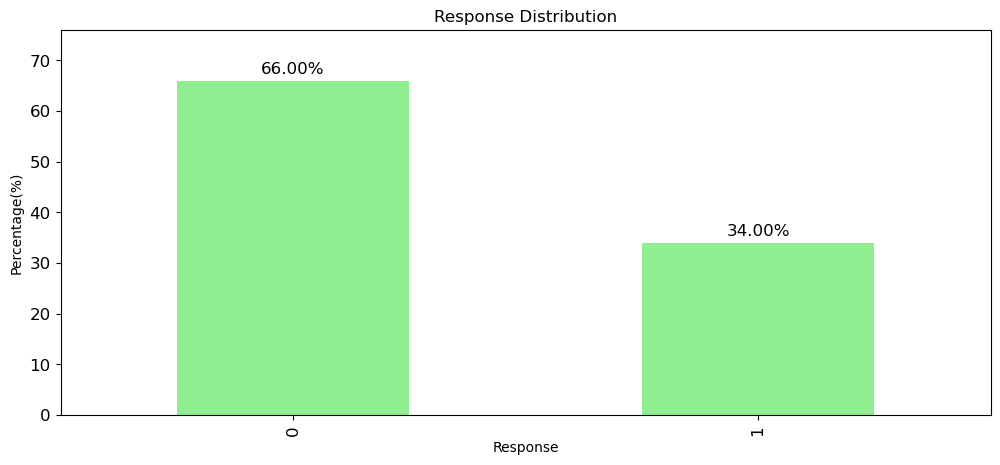

In [27]:
# Target value distribution of people who responded vs not responded


Responded_distribution = df['Responded'].value_counts(normalize=True)*100

ax = Responded_distribution.plot(kind='bar', figsize=(12,5), fontsize=12, color='lightgreen')

# % sign on top of bar
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3, fontsize=12)

# padding so the labels don't get cut off at the top
ax.set_ylim(0, Responded_distribution.max() + 10)

ax.set_xlabel("Response")
ax.set_ylabel("Percentage(%)")
ax.set_title("Response Distribution")
plt.show()


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
# Quantify the gap -- the range of each feature

ranges = (df.drop(columns='Responded').max() - df.drop(columns='Responded').min())
ranges.sort_values(ascending=False).round(1)

Days_Since_Last_Purchase    362.0
Age                          46.0
Annual_Income_Lakhs          36.0
Email_Opens_90Days           29.0
Past_Purchases                9.0
Has_Mobile_App                1.0
dtype: float64

# Scaling

In [37]:
X = df.drop(columns='Responded')
variance_X = X.var()

# get variance in %

raw_share = (variance_X / variance_X.sum() * 100).round(2).sort_values(ascending=False)
print('Average raw share in %')
print(raw_share)

Average raw share in %
Days_Since_Last_Purchase    97.15
Age                          1.67
Email_Opens_90Days           0.66
Annual_Income_Lakhs          0.50
Past_Purchases               0.02
Has_Mobile_App               0.00
dtype: float64


In [ ]:
variance_X.sort_values(ascending=False)  # variance in number

# So, we see the variance is very high for feature

Days_Since_Last_Purchase    11247.564645
Age                           193.251860
Email_Opens_90Days             76.350024
Annual_Income_Lakhs            57.937661
Past_Purchases                  2.643924
Has_Mobile_App                  0.250497
dtype: float64

In [40]:
# Put every feature on same scale using Z-score

# this blocks gives the variance % after scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled


,Age,Annual_Income_Lakhs,Past_Purchases,Email_Opens_90Days,Days_Since_Last_Purchase,Has_Mobile_App
0,-1.278983,1.615820,1.266939,0.340699,-0.962940,1.004008
1,-0.270889,1.010881,0.651322,-0.575775,1.160735,1.004008
2,-0.630923,0.734712,0.651322,-0.804893,0.471720,1.004008
3,-0.054869,0.774165,-1.811144,1.600851,0.566106,-0.996008
4,-0.990956,1.444859,0.651322,-0.002979,-0.934625,1.004008
...,...,...,...,...,...,...
495,0.521184,-1.422029,1.266939,-1.721367,-0.811923,1.004008
496,1.313258,-0.685581,-0.579911,0.569818,0.103616,1.004008
497,-0.054869,0.024566,-1.195527,-0.804893,-1.538692,1.004008
498,-0.702929,-0.869693,1.266939,0.455258,-0.651468,-0.996008


In [ ]:
# NOw check variance of each feature

var_scale = X_scaled.var()

scaled_share = (var_scale / var_scale.sum()*100).round(2)

print("Variance on scale X-train data")
scaled_share

# NOw the variance of each feature is same, the model won't be bias. Hence, scaling is imp in KNN

Variance on scale X-train data


Age                         16.67
Annual_Income_Lakhs         16.67
Past_Purchases              16.67
Email_Opens_90Days          16.67
Days_Since_Last_Purchase    16.67
Has_Mobile_App              16.67
dtype: float64

# Split and build KNN

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns='Responded')
y = df['Responded']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train)  # to avoid data leakage, so only tranform on test data
X_test_scale = scaler.transform(X_test)

print("Train:", X_train_scale.shape, "Test:", X_test_scale.shape)

Train: (375, 6) Test: (125, 6)


In [92]:
# Build KNN model where k=15

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=11)# by deafult it uses Minkowski distance  9
knn.fit(X_train_scale, y_train)

print("Training completed")

Training completed


In [93]:
y_pred = knn.predict(X_test_scale)

print("First 15 predictions:", y_pred[:15])
print("Actual 15 values    :",y_test.values[:15])  # as y_test is dataframe of dict, so get only the value

First 15 predictions: [1 0 0 0 0 1 1 0 0 0 0 0 0 1 0]
Actual 15 values    : [1 0 0 0 0 1 0 0 0 0 1 0 0 1 0]


# Evaluate

In [94]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy score", round(accuracy_score(y_test, y_pred),3), "\n")

print("Confusion Matrix\n", confusion_matrix(y_test, y_pred), "\n")
print("Classification report\n", classification_report(y_test, y_pred, target_names=['No', 'Responded']))

Accuracy score 0.752 

Confusion Matrix
 [[76  7]
 [24 18]] 

Classification report
               precision    recall  f1-score   support

          No       0.76      0.92      0.83        83
   Responded       0.72      0.43      0.54        42

    accuracy                           0.75       125
   macro avg       0.74      0.67      0.68       125
weighted avg       0.75      0.75      0.73       125



# Output explanation

- Accracy score = 0.752 ,which is good, where k=11
- CM: - TP - 18 people - Actual was Responded , model also said Responded.  - TN - 76 - Actual was Not Responded, Model also said Not responded
- FP - 7 people - Actual was noT Responded but model said responded -  This will waste companys time to call the customers who dose not respond. So, providing campagin for those is useless and waste of time
- FN - 24 people - Actual was Responded, model said nOT Responded - This will affect the business as the customers who responded were filtered out due to model's error

- The company should focus to imporve the value of Recall(FN) - so company would divert it's time to genuine customers where model predicated as not responded. FP is less which won't affect. But 24 genuine buyers is much risk

# Tune the Accuracy

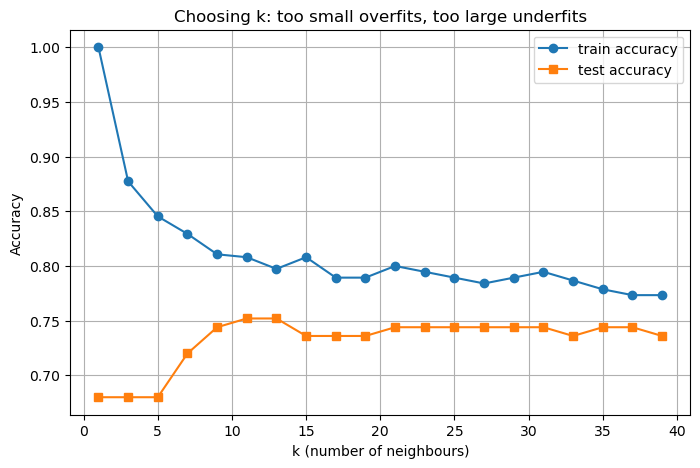

In [70]:
ks = range(1,40,2)
train_acc= []
test_acc = []

for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_scale,y_train)
    train_acc.append(m.score(X_train_scale,y_train))
    test_acc.append(m.score(X_test_scale, y_test))

plt.figure(figsize=(8, 5))
plt.plot(list(ks), train_acc, marker='o', label='train accuracy')
plt.plot(list(ks), test_acc, marker='s', label='test accuracy')
plt.xlabel('k (number of neighbours)')
plt.ylabel('Accuracy')
plt.title('Choosing k: too small overfits, too large underfits')
plt.legend()
plt.grid()


# Predict for new customer

In [ ]:
final = KNeighborsClassifier(n_neighbors=11).fit(X_train_scale, y_train)
cols = list(X.columns)


# Customer 1 with inputs for model to predict 
responder_like = pd.DataFrame([{
    'Age': 27, 'Annual_Income_Lakhs': 24.0, 'Past_Purchases': 6,
    'Email_Opens_90Days': 26, 'Days_Since_Last_Purchase': 30, 'Has_Mobile_App': 1}])[cols]   # to match the columns of old dataframe

# Customer 2 with inputs for model to predict
quiet_like = pd.DataFrame([{
    'Age': 55, 'Annual_Income_Lakhs': 8.0, 'Past_Purchases': 1,
    'Email_Opens_90Days': 3, 'Days_Since_Last_Purchase': 320, 'Has_Mobile_App': 0}])[cols]

for name, person in [('Engaged customer', responder_like), ('Dormant customer', quiet_like)]:
    ps = scaler.transform(person)
    p = final.predict_proba(ps)[0][1]

    print(f"{name} -> {"Respond" if final.predict(ps)[0]==1 else "no"}   p(respond) = {round(p,2)}")

p 0.7272727272727273
ps [[-0.87213742  1.09620591  1.90305369  1.26687797 -1.36817699  0.98675438]]
Engaged customer -> Respond   p(respond) = 0.73
p 0.0
ps [[ 1.14181528 -0.99446016 -1.20786669 -1.4231325   1.35191894 -1.01342342]]
Dormant customer -> no   p(respond) = 0.0
